In [ ]:
# ============================================================
# STEP 4 — ML DATASET PREPARATION
# Real Estate Buyer Segmentation Project
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from google.colab import files
import os


# ------------------------------------------------------------
# 2. UPLOAD EXCEL FILE
# ------------------------------------------------------------

print("Please upload: Real_Estate_ML.xlsx")

uploaded = files.upload()

# Find the uploaded Excel file
excel_file = None

for filename in uploaded.keys():
    if filename.lower().endswith((".xlsx", ".xls")):
        excel_file = filename
        break

if excel_file is None:
    raise FileNotFoundError(
        "Excel file not found. Please upload Real_Estate_ML.xlsx"
    )

print("\nFile uploaded successfully:")
print(excel_file)


# ------------------------------------------------------------
# 3. CHECK ALL SHEET NAMES
# ------------------------------------------------------------

xls = pd.ExcelFile(excel_file)

print("\nAvailable sheets:")
for i, sheet in enumerate(xls.sheet_names, start=1):
    print(i, ":", repr(sheet))


# ------------------------------------------------------------
# 4. FIND ML_DATASET SHEET
#    This handles extra spaces in sheet name
# ------------------------------------------------------------

ml_sheet = None

for sheet in xls.sheet_names:
    if sheet.strip().lower() == "ml_dataset":
        ml_sheet = sheet
        break

if ml_sheet is None:
    raise ValueError(
        "ML_Dataset sheet was not found. "
        "Please check the sheet name."
    )

print("\nSelected sheet:")
print(repr(ml_sheet))


# ------------------------------------------------------------
# 5. LOAD DATA
# ------------------------------------------------------------

df = pd.read_excel(
    excel_file,
    sheet_name=ml_sheet
)

print("\nDataset loaded successfully.")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ------------------------------------------------------------
# 6. CLEAN COLUMN NAMES
#    Remove unnecessary spaces
# ------------------------------------------------------------

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("\nColumn names in dataset:")

for col in df.columns:
    print("-", repr(col))


# ------------------------------------------------------------
# 7. CREATE A COPY FOR ML
# ------------------------------------------------------------

ml_df = df.copy()


# ------------------------------------------------------------
# 8. HELPER FUNCTION
#    Find column names even if capitalization/spaces differ
# ------------------------------------------------------------

def find_column(possible_names, columns):
    """
    Finds the first matching column from possible names.
    Matching is case-insensitive and ignores extra spaces.
    """

    normalized_columns = {
        str(col).strip().lower(): col
        for col in columns
    }

    for name in possible_names:

        key = str(name).strip().lower()

        if key in normalized_columns:
            return normalized_columns[key]

    return None


# ------------------------------------------------------------
# 9. IDENTIFY REQUIRED COLUMNS
# ------------------------------------------------------------

gender_col = find_column(
    ["gender"],
    ml_df.columns
)

country_col = find_column(
    ["country"],
    ml_df.columns
)

region_col = find_column(
    ["region"],
    ml_df.columns
)

client_type_col = find_column(
    ["client_type", "client type"],
    ml_df.columns
)

acquisition_col = find_column(
    ["acquisition_purpose", "acquisition purpose"],
    ml_df.columns
)

loan_col = find_column(
    ["loan_applied", "loan applied"],
    ml_df.columns
)

referral_col = find_column(
    ["referral_channel", "referral channel"],
    ml_df.columns
)

satisfaction_col = find_column(
    ["satisfaction_score", "satisfaction score"],
    ml_df.columns
)

sale_price_col = find_column(
    ["sale_price", "sale price"],
    ml_df.columns
)

floor_area_col = find_column(
    [
        "floor_area_sqft",
        "floor area sqft",
        "floor_area",
        "floor area"
    ],
    ml_df.columns
)

client_ref_col = find_column(
    ["client_ref", "client ref"],
    ml_df.columns
)


# ------------------------------------------------------------
# 10. SHOW COLUMN MATCHING
# ------------------------------------------------------------

print("\n================================================")
print("COLUMN DETECTION")
print("================================================")

print("Client Ref            :", client_ref_col)
print("Gender                :", gender_col)
print("Country               :", country_col)
print("Region                :", region_col)
print("Client Type           :", client_type_col)
print("Acquisition Purpose   :", acquisition_col)
print("Loan Applied          :", loan_col)
print("Referral Channel      :", referral_col)
print("Satisfaction Score    :", satisfaction_col)
print("Sale Price            :", sale_price_col)
print("Floor Area Sqft       :", floor_area_col)


# ------------------------------------------------------------
# 11. CHECK IMPORTANT COLUMNS
# ------------------------------------------------------------

required_columns = {
    "Gender": gender_col,
    "Country": country_col,
    "Region": region_col,
    "Client Type": client_type_col,
    "Acquisition Purpose": acquisition_col,
    "Loan Applied": loan_col,
    "Referral Channel": referral_col,
    "Satisfaction Score": satisfaction_col,
    "Sale Price": sale_price_col,
    "Floor Area Sqft": floor_area_col
}

missing_columns = [
    name
    for name, col in required_columns.items()
    if col is None
]

if missing_columns:

    print("\nMissing columns:")
    for col in missing_columns:
        print("-", col)

    raise ValueError(
        "Some required columns were not found. "
        "Check the column names printed above."
    )

print("\nAll required ML columns found successfully.")


# ------------------------------------------------------------
# 12. SELECT ORIGINAL ML FEATURES
#
# IMPORTANT:
# AGE IS NOT INCLUDED
# CLIENT_REF IS NOT INCLUDED AS A ML FEATURE
# ------------------------------------------------------------

categorical_columns = [
    gender_col,
    country_col,
    region_col,
    client_type_col,
    acquisition_col,
    loan_col,
    referral_col
]

numerical_columns = [
    satisfaction_col,
    sale_price_col,
    floor_area_col
]

print("\nCategorical columns:")
for col in categorical_columns:
    print("-", col)

print("\nNumerical columns:")
for col in numerical_columns:
    print("-", col)


# ------------------------------------------------------------
# 13. PREPARE CATEGORICAL DATA
# ------------------------------------------------------------

X_categorical = ml_df[categorical_columns].copy()

# Convert categorical values to strings
# This prevents datatype problems during encoding

for col in categorical_columns:

    X_categorical[col] = (
        X_categorical[col]
        .astype("string")
        .str.strip()
    )

# Replace missing values
X_categorical = X_categorical.fillna("Unknown")


# ------------------------------------------------------------
# 14. ONE-HOT ENCODING
# ------------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_encoded_array = encoder.fit_transform(
    X_categorical
)

# Get generated feature names
encoded_feature_names = encoder.get_feature_names_out(
    categorical_columns
)

# Convert encoded data into DataFrame
X_encoded = pd.DataFrame(
    X_encoded_array,
    columns=encoded_feature_names,
    index=ml_df.index
)

print("\n================================================")
print("ONE-HOT ENCODING COMPLETED")
print("================================================")

print("Original categorical columns:",
      len(categorical_columns))

print("Encoded columns:",
      X_encoded.shape[1])

print("\nFirst 5 rows of encoded data:")
display(X_encoded.head())


# ------------------------------------------------------------
# 15. PREPARE NUMERICAL DATA
# ------------------------------------------------------------

X_numerical = ml_df[numerical_columns].copy()

# Convert values to numeric
for col in numerical_columns:

    X_numerical[col] = pd.to_numeric(
        X_numerical[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# 16. HANDLE MISSING NUMERICAL VALUES
# ------------------------------------------------------------

for col in numerical_columns:

    if X_numerical[col].isna().sum() > 0:

        X_numerical[col] = X_numerical[col].fillna(
            X_numerical[col].median()
        )


# ------------------------------------------------------------
# 17. STANDARD SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(
    X_numerical
)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=[
        "Scaled_Satisfaction_Score",
        "Scaled_Sale_Price",
        "Scaled_Floor_Area_Sqft"
    ],
    index=ml_df.index
)

print("\n================================================")
print("NUMERICAL SCALING COMPLETED")
print("================================================")

print("\nFirst 5 rows of scaled data:")
display(X_scaled.head())


# ------------------------------------------------------------
# 18. COMBINE ENCODED + SCALED DATA
# ------------------------------------------------------------

X_final = pd.concat(
    [
        X_encoded,
        X_scaled
    ],
    axis=1
)

print("\n================================================")
print("FINAL ML FEATURE MATRIX")
print("================================================")

print("Rows:", X_final.shape[0])
print("Columns:", X_final.shape[1])

print("\nFirst 5 rows:")
display(X_final.head())


# ------------------------------------------------------------
# 19. CHECK FOR MISSING VALUES
# ------------------------------------------------------------

missing_values = X_final.isna().sum().sum()

print("\nTotal missing values in X_final:",
      missing_values)


# ------------------------------------------------------------
# 20. CHECK DATA TYPE
# ------------------------------------------------------------

print("\nData types in X_final:")

print(
    X_final.dtypes.value_counts()
)


# ------------------------------------------------------------
# 21. CHECK THAT EVERYTHING IS NUMERIC
# ------------------------------------------------------------

non_numeric_columns = X_final.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if len(non_numeric_columns) == 0:

    print(
        "\nSUCCESS: All ML features are numeric."
    )

else:

    print(
        "\nWARNING: Non-numeric columns found:"
    )

    for col in non_numeric_columns:
        print("-", col)


# ------------------------------------------------------------
# 22. CREATE FINAL ML DATASET
#
# Keep Client Ref separately only for identification.
# It is NOT used as an ML feature.
# ------------------------------------------------------------

if client_ref_col is not None:

    ml_output = pd.concat(
        [
            ml_df[[client_ref_col]].reset_index(drop=True),
            X_final.reset_index(drop=True)
        ],
        axis=1
    )

else:

    ml_output = X_final.reset_index(drop=True)


# ------------------------------------------------------------
# 23. DISPLAY FINAL DATASET
# ------------------------------------------------------------

print("\n================================================")
print("FINAL ML DATASET")
print("================================================")

print("Shape:",
      ml_output.shape)

display(ml_output.head())


# ------------------------------------------------------------
# 24. SAVE FINAL ML DATASET
# ------------------------------------------------------------

output_file = "Real_Estate_ML_Ready.xlsx"

ml_output.to_excel(
    output_file,
    index=False
)

print(
    "\nFinal ML-ready file created successfully:"
)

print(output_file)


# ------------------------------------------------------------
# 25. SAVE ENCODER INFORMATION
# ------------------------------------------------------------

encoder_columns = pd.DataFrame({
    "Encoded_Feature": encoded_feature_names
})

encoder_columns.to_csv(
    "Encoded_Feature_Names.csv",
    index=False
)


# ------------------------------------------------------------
# 26. DOWNLOAD FINAL FILE
# ------------------------------------------------------------

files.download(output_file)

print("\n================================================")
print("STEP 4 COMPLETED SUCCESSFULLY")
print("================================================")
print("Age was NOT used.")
print("Client Ref was NOT used as an ML feature.")
print("Categorical variables were One-Hot Encoded.")
print("Numerical variables were Standard Scaled.")
print("Final ML dataset is ready for the next step.")

Please upload: Real_Estate_ML.xlsx


Saving Real_Estate_ML.xlsx to Real_Estate_ML.xlsx

File uploaded successfully:
Real_Estate_ML.xlsx

Available sheets:
1 : 'ML_Dataset '
2 : 'ML_Dataset 1'
3 : 'Real_Estate_Feature_Encoded.xls'
4 : 'EDA'
5 : 'Individual vs Corporate Buyers'
6 : 'Gender-wise Buyer'
7 : 'Country-wise Buyer '
8 : 'Sheet4'
9 : 'Region-wise Buyer Distribution'
10 : 'Home vs Investment Buyers'
11 : 'Loan Application Behaviour'
12 : 'Sheet11'
13 : 'Referral Channel'
14 : 'Satisfaction Score'
15 : 'Property Price Distribution'
16 : 'EDA_Size_vs_Price'
17 : 'EDA_Investment_Loan'
18 : 'EDA_Country_Investment'
19 : 'EDA_ClientType_Investment'
20 : 'Sheet16'
21 : 'EDA_Satisfaction_Purpose'

Selected sheet:
'ML_Dataset '

Dataset loaded successfully.
Rows: 7305
Columns: 21

Column names in dataset:
- 'floor_area_sqft'
- 'sale_price'
- 'client_ref'
- 'client_type'
- 'Client_Type_Company'
- 'Client_Type_Individual'
- 'gender'
- 'gender _encoding'
- 'country'
- 'region'
- 'acquisition_purpose'
- 'acquisition purpose en

,gender_F,gender_M,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,country_Russia,...,region_Zealand,client_type_Company,client_type_Individual,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0



NUMERICAL SCALING COMPLETED

First 5 rows of scaled data:


,Scaled_Satisfaction_Score,Scaled_Sale_Price,Scaled_Floor_Area_Sqft
0,1.375909,-0.338419,0.045829
1,1.375909,-1.016376,-0.915878
2,1.375909,-1.031023,-0.856123
3,1.375909,-0.870478,-0.792170
4,-1.448997,-0.347055,-0.483234


...

,client_ref,gender_F,gender_M,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,...,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website,Scaled_Satisfaction_Score,Scaled_Sale_Price,Scaled_Floor_Area_Sqft
0,C0027,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.375909,-0.338419,0.045829
1,C0027,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.375909,-1.016376,-0.915878
2,C0097,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.375909,-1.031023,-0.856123
3,C0097,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.375909,-0.870478,-0.792170
4,C0002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.448997,-0.347055,-0.483234



Final ML-ready file created successfully:
Real_Estate_ML_Ready.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


STEP 4 COMPLETED SUCCESSFULLY
Age was NOT used.
Client Ref was NOT used as an ML feature.
Categorical variables were One-Hot Encoded.
Numerical variables were Standard Scaled.
Final ML dataset is ready for the next step.


Libraries imported successfully!
Available sheets:
['Sheet1']

Using sheet: Sheet1

Dataset loaded successfully!
Rows: 7305
Columns: 82

First 5 rows:


,client_ref,gender_F,gender_M,country_Australia,country_Belgium,country_Canada,country_Denmark,country_France,country_Germany,country_Mexico,...,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website,Scaled_Satisfaction_Score,Scaled_Sale_Price,Scaled_Floor_Area_Sqft
0,C0027,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1.375909,-0.338419,0.045829
1,C0027,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1.375909,-1.016376,-0.915878
2,C0097,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1.375909,-1.031023,-0.856123
3,C0097,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1.375909,-0.870478,-0.792170
4,C0002,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,0,1,-1.448997,-0.347055,-0.483234



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_ref                      7305 non-null   object 
 1   gender_F                        7305 non-null   int64  
 2   gender_M                        7305 non-null   int64  
 3   country_Australia               7305 non-null   int64  
 4   country_Belgium                 7305 non-null   int64  
 5   country_Canada                  7305 non-null   int64  
 6   country_Denmark                 7305 non-null   int64  
 7   country_France                  7305 non-null   int64  
 8   country_Germany                 7305 non-null   int64  
 9   country_Mexico                  7305 non-null   int64  
 10  country_Russia                  7305 non-null   int64  
 11  country_UK                      7305 non-null   int64  
 12  country_USA 

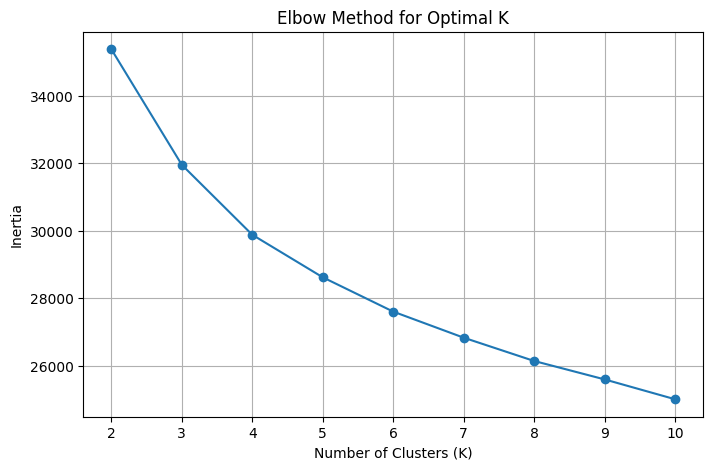

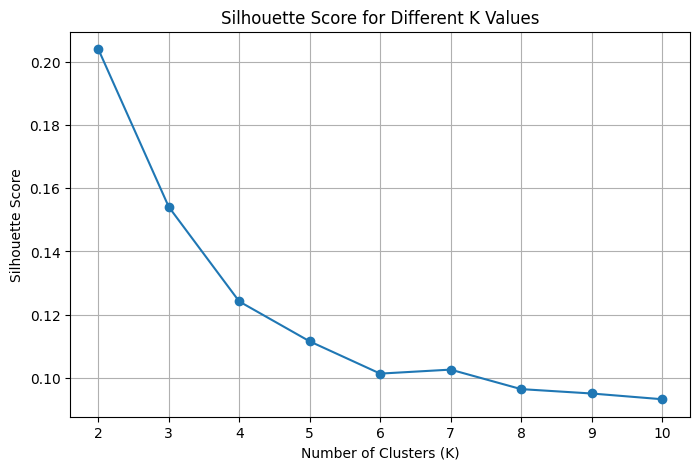


K-Means evaluation results:


,K,Inertia,Silhouette_Score
0,2,35375.025704,0.204004
1,3,31952.934854,0.154093
2,4,29881.203527,0.124177
3,5,28622.222927,0.111552
4,6,27605.866364,0.101348
5,7,26834.139417,0.102611
6,8,26143.937745,0.096440
7,9,25598.574610,0.095055
8,10,25011.083685,0.093242



Recommended number of clusters: 2

Cluster column added successfully!

Cluster distribution:


,Number_of_Records
Cluster,
0,4068
1,3237



Cluster Summary:


,Cluster,Number_of_Records,Percentage
0,0,4068,55.69
1,1,3237,44.31


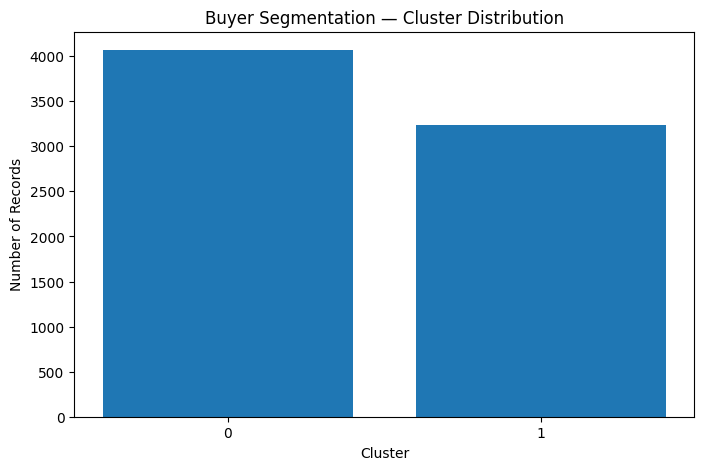

Original numerical columns not found in final dataset.

Categorical columns available:
[]

Complete Cluster Profile:


,Cluster,Records
0,0,4068
1,1,3237



STEP 5 COMPLETED SUCCESSFULLY!

Best K = 2

Final output file:
Real_Estate_Buyer_Segmentation.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Your Buyer Segmentation Excel file is ready!


In [ ]:
# ============================================================
# STEP 5 — BUYER SEGMENTATION USING K-MEANS CLUSTERING
# ============================================================

# -------------------------------
# PART 1 — IMPORT LIBRARIES
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")


# ============================================================
# PART 2 — LOAD THE ML-READY DATA
# ============================================================

# Agar STEP 4 me ye file ban chuki hai:
file_name = "Real_Estate_ML_Ready.xlsx"

# Excel ki sheets check karna
excel_file = pd.ExcelFile(file_name)

print("Available sheets:")
print(excel_file.sheet_names)


# ML-ready sheet automatically find karna
sheet_name = None

for s in excel_file.sheet_names:
    if s.strip().lower() in ["ml_ready", "ml_dataset", "ml_encoded"]:
        sheet_name = s
        break

# Agar matching sheet nahi mili to first sheet use hogi
if sheet_name is None:
    sheet_name = excel_file.sheet_names[0]

print("\nUsing sheet:", sheet_name)

df_ml = pd.read_excel(file_name, sheet_name=sheet_name)

print("\nDataset loaded successfully!")
print("Rows:", df_ml.shape[0])
print("Columns:", df_ml.shape[1])

print("\nFirst 5 rows:")
display(df_ml.head())


# ============================================================
# PART 3 — CHECK DATA
# ============================================================

print("\nDataset information:")
print(df_ml.info())

print("\nMissing values:")
print(df_ml.isnull().sum().sum())

print("\nShape:")
print(df_ml.shape)


# ============================================================
# PART 4 — PREPARE DATA FOR K-MEANS
# ============================================================

# client_ref identification ke liye hai.
# Isko ML clustering feature nahi banayenge.

if "client_ref" in df_ml.columns:
    X = df_ml.drop(columns=["client_ref"]).copy()
else:
    X = df_ml.copy()

# Sirf numeric columns K-Means me jayenge
X = X.select_dtypes(include=[np.number])

print("\nFeatures used for K-Means:")
print(X.columns.tolist())

print("\nNumber of ML features:", X.shape[1])


# ============================================================
# PART 5 — REMOVE ANY MISSING VALUES
# ============================================================

# Agar kisi numerical column me missing value hai,
# median se fill karenge.

X = X.fillna(X.median(numeric_only=True))

print("\nMissing values after cleaning:")
print(X.isnull().sum().sum())


# ============================================================
# PART 6 — ELBOW METHOD
# ============================================================

# K = 2 se K = 10 tak test karenge

inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)


# Elbow graph

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()


# ============================================================
# PART 7 — SILHOUETTE SCORE
# ============================================================

# Elbow graph ke saath silhouette score bhi check karenge.

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)


# Silhouette graph

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()


# Table of results

k_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "Silhouette_Score": silhouette_scores
})

print("\nK-Means evaluation results:")
display(k_results)


# ============================================================
# PART 8 — AUTOMATICALLY SELECT BEST K
# ============================================================

# Highest silhouette score wala K select karenge.

best_k = k_results.loc[
    k_results["Silhouette_Score"].idxmax(),
    "K"
]

best_k = int(best_k)

print("\nRecommended number of clusters:", best_k)


# ============================================================
# PART 9 — FINAL K-MEANS MODEL
# ============================================================

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X)


# ============================================================
# PART 10 — ADD CLUSTER TO ORIGINAL DATA
# ============================================================

df_clustered = df_ml.copy()

df_clustered["Cluster"] = cluster_labels

print("\nCluster column added successfully!")

print("\nCluster distribution:")

cluster_distribution = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

display(cluster_distribution.to_frame("Number_of_Records"))


# ============================================================
# PART 11 — CLUSTER PERCENTAGE
# ============================================================

cluster_percentage = (
    df_clustered["Cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_summary = pd.DataFrame({
    "Cluster": cluster_percentage.index,
    "Number_of_Records": cluster_distribution.values,
    "Percentage": cluster_percentage.values
})

cluster_summary["Percentage"] = cluster_summary["Percentage"].round(2)

print("\nCluster Summary:")
display(cluster_summary)


# ============================================================
# PART 12 — CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_summary["Cluster"].astype(str),
    cluster_summary["Number_of_Records"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.title("Buyer Segmentation — Cluster Distribution")

plt.show()


# ============================================================
# PART 13 — CLUSTER PROFILE
# ============================================================

# Numerical variables ka cluster-wise average

numeric_columns = [
    col for col in [
        "satisfaction_score",
        "sale_price",
        "floor_area_sqft"
    ]
    if col in df_clustered.columns
]

if len(numeric_columns) > 0:

    cluster_profile_numeric = (
        df_clustered
        .groupby("Cluster")[numeric_columns]
        .mean()
        .round(2)
    )

    print("\nCluster-wise Numerical Profile:")
    display(cluster_profile_numeric)

else:

    print("Original numerical columns not found in final dataset.")


# ============================================================
# PART 14 — CLUSTER-WISE MEDIAN
# ============================================================

if len(numeric_columns) > 0:

    cluster_median = (
        df_clustered
        .groupby("Cluster")[numeric_columns]
        .median()
        .round(2)
    )

    print("\nCluster-wise Median:")
    display(cluster_median)


# ============================================================
# PART 15 — ORIGINAL CATEGORICAL DATA PROFILE
# ============================================================

# Original categorical columns available hain to
# cluster ke according unka distribution dekhenge.

categorical_columns = [
    col for col in [
        "gender",
        "country",
        "region",
        "client_type",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel"
    ]
    if col in df_clustered.columns
]

print("\nCategorical columns available:")
print(categorical_columns)


# ============================================================
# PART 16 — MOST COMMON CATEGORY IN EACH CLUSTER
# ============================================================

profile_data = []

for cluster in sorted(df_clustered["Cluster"].unique()):

    cluster_data = df_clustered[
        df_clustered["Cluster"] == cluster
    ]

    row = {
        "Cluster": cluster,
        "Records": len(cluster_data)
    }

    for col in categorical_columns:

        if len(cluster_data[col].dropna()) > 0:

            mode_value = cluster_data[col].mode()

            if len(mode_value) > 0:
                row[col + "_Most_Common"] = mode_value.iloc[0]

    for col in numeric_columns:

        row["Average_" + col] = round(
            cluster_data[col].mean(), 2
        )

    profile_data.append(row)


cluster_profile = pd.DataFrame(profile_data)

print("\nComplete Cluster Profile:")
display(cluster_profile)


# ============================================================
# PART 17 — COUNTRY-WISE CLUSTER ANALYSIS
# ============================================================

if "country" in df_clustered.columns:

    country_cluster = pd.crosstab(
        df_clustered["country"],
        df_clustered["Cluster"]
    )

    print("\nCountry-wise Cluster Distribution:")
    display(country_cluster)


# ============================================================
# PART 18 — INVESTMENT / HOME BY CLUSTER
# ============================================================

if "acquisition_purpose" in df_clustered.columns:

    purpose_cluster = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["acquisition_purpose"]
    )

    print("\nAcquisition Purpose by Cluster:")
    display(purpose_cluster)


# ============================================================
# PART 19 — LOAN BY CLUSTER
# ============================================================

if "loan_applied" in df_clustered.columns:

    loan_cluster = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["loan_applied"]
    )

    print("\nLoan Application by Cluster:")
    display(loan_cluster)


# ============================================================
# PART 20 — CLIENT TYPE BY CLUSTER
# ============================================================

if "client_type" in df_clustered.columns:

    client_type_cluster = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["client_type"]
    )

    print("\nClient Type by Cluster:")
    display(client_type_cluster)


# ============================================================
# PART 21 — REFERRAL CHANNEL BY CLUSTER
# ============================================================

if "referral_channel" in df_clustered.columns:

    referral_cluster = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["referral_channel"]
    )

    print("\nReferral Channel by Cluster:")
    display(referral_cluster)


# ============================================================
# PART 22 — GENDER BY CLUSTER
# ============================================================

if "gender" in df_clustered.columns:

    gender_cluster = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered["gender"]
    )

    print("\nGender by Cluster:")
    display(gender_cluster)


# ============================================================
# PART 23 — SAVE FINAL CLUSTERED DATA
# ============================================================

output_file = "Real_Estate_Buyer_Segmentation.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Original data + cluster
    df_clustered.to_excel(
        writer,
        sheet_name="Clustered_Data",
        index=False
    )

    # Cluster summary
    cluster_summary.to_excel(
        writer,
        sheet_name="Cluster_Summary",
        index=False
    )

    # Cluster profile
    cluster_profile.to_excel(
        writer,
        sheet_name="Cluster_Profile",
        index=False
    )

    # Numerical profile
    if len(numeric_columns) > 0:

        cluster_profile_numeric.to_excel(
            writer,
            sheet_name="Numerical_Profile"
        )

    # Country analysis
    if "country" in df_clustered.columns:

        country_cluster.to_excel(
            writer,
            sheet_name="Country_Cluster"
        )

    # Acquisition purpose
    if "acquisition_purpose" in df_clustered.columns:

        purpose_cluster.to_excel(
            writer,
            sheet_name="Purpose_Cluster"
        )

    # Loan
    if "loan_applied" in df_clustered.columns:

        loan_cluster.to_excel(
            writer,
            sheet_name="Loan_Cluster"
        )

    # Client type
    if "client_type" in df_clustered.columns:

        client_type_cluster.to_excel(
            writer,
            sheet_name="ClientType_Cluster"
        )

    # Referral
    if "referral_channel" in df_clustered.columns:

        referral_cluster.to_excel(
            writer,
            sheet_name="Referral_Cluster"
        )

    # Gender
    if "gender" in df_clustered.columns:

        gender_cluster.to_excel(
            writer,
            sheet_name="Gender_Cluster"
        )


print("\n================================================")
print("STEP 5 COMPLETED SUCCESSFULLY!")
print("================================================")

print("\nBest K =", best_k)

print("\nFinal output file:")
print(output_file)


# ============================================================
# PART 24 — DOWNLOAD FILE
# ============================================================

from google.colab import files

files.download(output_file)

print("\nYour Buyer Segmentation Excel file is ready!")

Libraries imported successfully!
Please upload your Real Estate Excel/CSV file.


Saving Real_Estate_ML.xlsx to Real_Estate_ML (1).xlsx

Uploaded file(s):
['Real_Estate_ML (1).xlsx']

Using Excel file: Real_Estate_ML (1).xlsx

Available sheets:
['ML_Dataset ', 'ML_Dataset 1', 'Real_Estate_Feature_Encoded.xls', 'EDA', 'Individual vs Corporate Buyers', 'Gender-wise Buyer', 'Country-wise Buyer ', 'Sheet4', 'Region-wise Buyer Distribution', 'Home vs Investment Buyers', 'Loan Application Behaviour', 'Sheet11', 'Referral Channel', 'Satisfaction Score', 'Property Price Distribution', 'EDA_Size_vs_Price', 'EDA_Investment_Loan', 'EDA_Country_Investment', 'EDA_ClientType_Investment', 'Sheet16', 'EDA_Satisfaction_Purpose']

Using sheet: ML_Dataset 

Dataset loaded successfully!
Rows: 7305
Columns: 21

Columns:
['floor_area_sqft', 'sale_price', 'client_ref', 'client_type', 'Client_Type_Company', 'Client_Type_Individual', 'gender', 'gender _encoding', 'country', 'region', 'acquisition_purpose', 'acquisition purpose encoding', 'satisfaction_score', 'loan_applied', 'Loan_No', 'Loa

,client_ref,gender,country,region,client_type,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,sale_price,floor_area_sqft,property_count
0,C0001,F,USA,California,Individual,Home,Yes,Website,4.0,311691.180000,983.885000,4
1,C0002,M,USA,California,Individual,Home,No,Website,1.0,368219.186000,1187.942000,5
2,C0003,M,USA,California,Individual,Home,Yes,Agency,4.0,332291.518000,1058.110000,5
3,C0004,M,USA,California,Individual,Home,No,Website,5.0,268043.918333,937.103333,6
4,C0005,M,USA,California,Company,Investment,No,Website,5.0,281029.644615,927.296154,13



Total missing values after cleaning:
0

Encoded categorical features: 78
Scaled numerical features: 4

FINAL ML DATA
Buyers: 2000
Features: 82


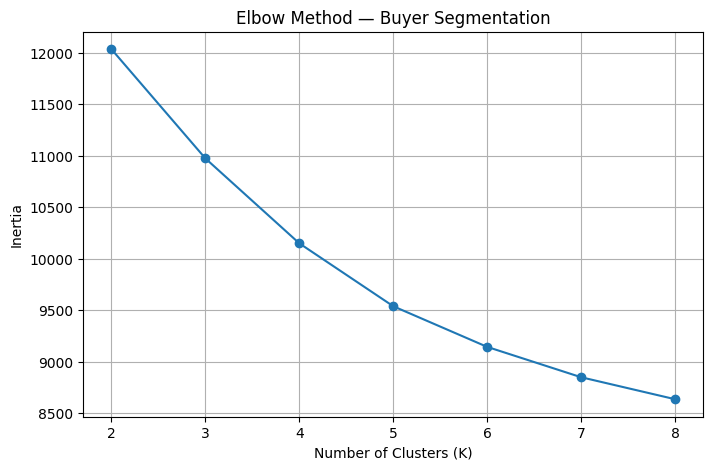

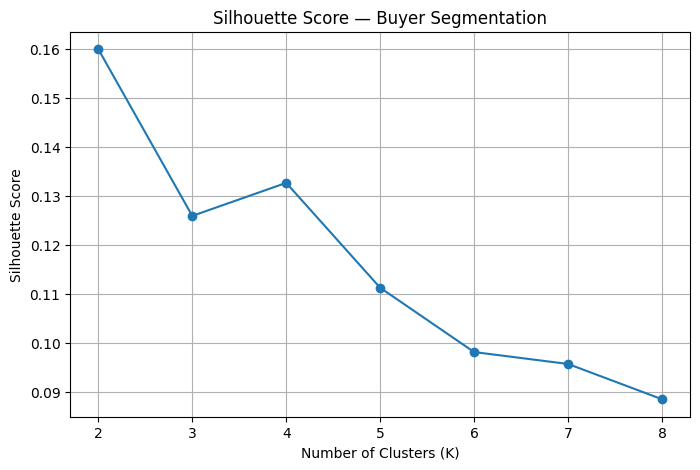


K Evaluation Results:


,K,Inertia,Silhouette_Score
0,2,12032.258077,0.1600
1,3,10972.357128,0.1260
2,4,10147.867734,0.1327
3,5,9537.222332,0.1113
4,6,9142.690979,0.0982
5,7,8848.210250,0.0958
6,8,8634.852683,0.0886



Recommended Number of Clusters: 2

K-Means clustering completed!

BUYER CLUSTER SUMMARY


,Cluster,Number_of_Buyers,Percentage
0,0,793,39.65
1,1,1207,60.35


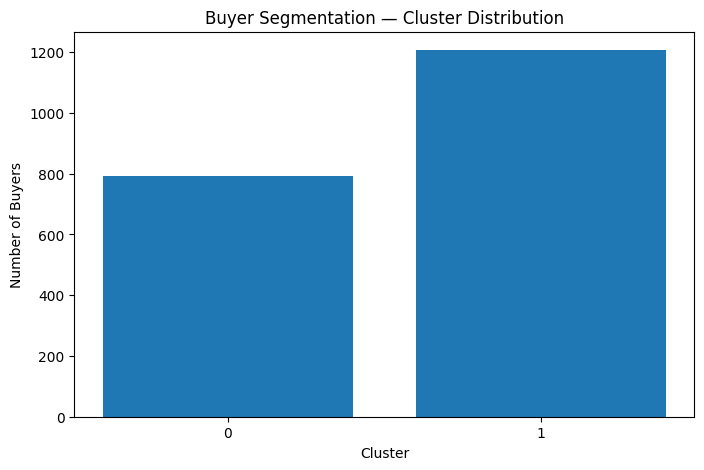


NUMERICAL CLUSTER PROFILE


,satisfaction_score,sale_price,floor_area_sqft,property_count
Cluster,,,,
0,3.05,415522.84,1365.95,3.47
1,3.01,302129.50,1003.94,3.77



COMPLETE BUYER CLUSTER PROFILE


,Cluster,Number_of_Buyers,Average_satisfaction_score,Average_sale_price,Average_floor_area_sqft,Average_property_count,Most_Common_gender,Most_Common_country,Most_Common_region,Most_Common_client_type,Most_Common_acquisition_purpose,Most_Common_loan_applied,Most_Common_referral_channel
0,0,793,3.05,415522.84,1365.95,3.47,M,USA,California,Individual,Home,No,Website
1,1,1207,3.01,302129.50,1003.94,3.77,F,USA,California,Individual,Home,No,Website



Acquisition Purpose by Cluster:


...


Country by Cluster:


country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,14,15,34,9,23,22,15,14,42,605
1,25,28,51,6,30,34,25,22,53,933


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


STEP 5 COMPLETED SUCCESSFULLY!
Total unique buyers: 2000
Best K: 2
Final file: Real_Estate_Buyer_Segmentation_Final.xlsx


In [ ]:
# ============================================================
# STEP 5 — CORRECT BUYER SEGMENTATION
# FILE UPLOAD + K-MEANS
# ============================================================

# ------------------------------------------------------------
# PART 1 — IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from google.colab import files

print("Libraries imported successfully!")


# ------------------------------------------------------------
# PART 2 — UPLOAD YOUR FILE
# ------------------------------------------------------------

print("Please upload your Real Estate Excel/CSV file.")

uploaded = files.upload()

print("\nUploaded file(s):")
print(list(uploaded.keys()))


# ------------------------------------------------------------
# PART 3 — FIND THE FILE AUTOMATICALLY
# ------------------------------------------------------------

file_names = list(uploaded.keys())

csv_files = [
    f for f in file_names
    if f.lower().endswith(".csv")
]

excel_files = [
    f for f in file_names
    if f.lower().endswith((".xlsx", ".xls"))
]


# ------------------------------------------------------------
# PART 4 — LOAD DATA
# ------------------------------------------------------------

if len(csv_files) > 0:

    # CSV available hai
    file_name = csv_files[0]

    print("\nUsing CSV file:", file_name)

    df = pd.read_csv(file_name)


elif len(excel_files) > 0:

    # Excel available hai
    file_name = excel_files[0]

    print("\nUsing Excel file:", file_name)

    excel_file = pd.ExcelFile(file_name)

    print("\nAvailable sheets:")
    print(excel_file.sheet_names)

    # ML_Dataset sheet automatically find karna
    sheet_name = None

    for s in excel_file.sheet_names:

        if s.strip().lower() == "ml_dataset":
            sheet_name = s
            break

    # Agar ML_Dataset nahi mila
    if sheet_name is None:

        sheet_name = excel_file.sheet_names[0]

        print(
            "\nML_Dataset sheet nahi mili."
            " First sheet use ho rahi hai:"
        )

    else:

        print("\nUsing sheet:", sheet_name)

    df = pd.read_excel(
        file_name,
        sheet_name=sheet_name
    )


else:

    raise Exception(
        "Please upload a CSV or Excel file."
    )


# ------------------------------------------------------------
# PART 5 — CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

print("\nDataset loaded successfully!")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# PART 6 — CHECK CLIENT_REF
# ------------------------------------------------------------

if "client_ref" not in df.columns:

    raise Exception(
        "client_ref column nahi mila. "
        "Please original dataset upload karein."
    )


# ------------------------------------------------------------
# PART 7 — UNIQUE BUYERS
# ------------------------------------------------------------

total_records = len(df)

total_buyers = df["client_ref"].nunique()

print("\n======================================")
print("DATASET CHECK")
print("======================================")

print("Total property records:", total_records)

print("Total unique buyers:", total_buyers)


# ------------------------------------------------------------
# PART 8 — CREATE BUYER-LEVEL DATA
# ------------------------------------------------------------

required_columns = [
    "gender",
    "country",
    "region",
    "client_type",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel",
    "satisfaction_score",
    "sale_price",
    "floor_area_sqft"
]


# Check which columns are available
available_columns = [
    col for col in required_columns
    if col in df.columns
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("\nAvailable project columns:")
print(available_columns)

if len(missing_columns) > 0:

    print("\nWarning — missing columns:")
    print(missing_columns)


# ------------------------------------------------------------
# PART 9 — BUYER AGGREGATION
# ------------------------------------------------------------

aggregation_rules = {}


# Categorical columns
for col in [
    "gender",
    "country",
    "region",
    "client_type",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]:

    if col in df.columns:

        aggregation_rules[col] = "first"


# Numerical columns
for col in [
    "satisfaction_score",
    "sale_price",
    "floor_area_sqft"
]:

    if col in df.columns:

        aggregation_rules[col] = "mean"


# Property count
aggregation_rules["_property_count"] = "count"


# Create temporary column for counting
df["_property_count"] = 1


buyer_data = (
    df
    .groupby("client_ref")
    .agg(aggregation_rules)
    .reset_index()
)


buyer_data = buyer_data.rename(
    columns={
        "_property_count": "property_count"
    }
)


print("\n======================================")
print("BUYER-LEVEL DATA CREATED")
print("======================================")

print(
    "Number of buyers:",
    buyer_data.shape[0]
)

print(
    "Number of columns:",
    buyer_data.shape[1]
)

display(buyer_data.head())


# ------------------------------------------------------------
# PART 10 — MISSING VALUES
# ------------------------------------------------------------

categorical_columns = [
    col for col in [
        "gender",
        "country",
        "region",
        "client_type",
        "acquisition_purpose",
        "loan_applied",
        "referral_channel"
    ]
    if col in buyer_data.columns
]


numerical_columns = [
    col for col in [
        "satisfaction_score",
        "sale_price",
        "floor_area_sqft",
        "property_count"
    ]
    if col in buyer_data.columns
]


# Fill categorical missing values
for col in categorical_columns:

    buyer_data[col] = (
        buyer_data[col]
        .fillna("Unknown")
        .astype(str)
    )


# Fill numerical missing values
for col in numerical_columns:

    buyer_data[col] = pd.to_numeric(
        buyer_data[col],
        errors="coerce"
    )

    buyer_data[col] = buyer_data[col].fillna(
        buyer_data[col].median()
    )


print("\nTotal missing values after cleaning:")

print(
    buyer_data.isnull().sum().sum()
)


# ------------------------------------------------------------
# PART 11 — ONE-HOT ENCODING
# ------------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)


if len(categorical_columns) > 0:

    X_categorical = encoder.fit_transform(
        buyer_data[categorical_columns]
    )

else:

    X_categorical = np.empty(
        (len(buyer_data), 0)
    )


print(
    "\nEncoded categorical features:",
    X_categorical.shape[1]
)


# ------------------------------------------------------------
# PART 12 — SCALE NUMERICAL DATA
# ------------------------------------------------------------

if len(numerical_columns) > 0:

    scaler = StandardScaler()

    X_numerical = scaler.fit_transform(
        buyer_data[numerical_columns]
    )

else:

    X_numerical = np.empty(
        (len(buyer_data), 0)
    )


print(
    "Scaled numerical features:",
    X_numerical.shape[1]
)


# ------------------------------------------------------------
# PART 13 — FINAL ML DATA
# ------------------------------------------------------------

X_final = np.hstack([
    X_categorical,
    X_numerical
])


print("\n======================================")
print("FINAL ML DATA")
print("======================================")

print("Buyers:", X_final.shape[0])

print("Features:", X_final.shape[1])


# ------------------------------------------------------------
# PART 14 — ELBOW METHOD
# ------------------------------------------------------------

inertia = []

K_range = range(2, 9)


for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_final)

    inertia.append(
        model.inertia_
    )


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title(
    "Elbow Method — Buyer Segmentation"
)

plt.xticks(list(K_range))

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# PART 15 — SILHOUETTE SCORE
# ------------------------------------------------------------

silhouette_scores = []


for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(
        X_final
    )

    score = silhouette_score(
        X_final,
        labels
    )

    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Score — Buyer Segmentation"
)

plt.xticks(list(K_range))

plt.grid(True)

plt.show()


# ------------------------------------------------------------
# PART 16 — K EVALUATION TABLE
# ------------------------------------------------------------

k_results = pd.DataFrame({

    "K": list(K_range),

    "Inertia": inertia,

    "Silhouette_Score":
        np.round(
            silhouette_scores,
            4
        )
})


print("\nK Evaluation Results:")

display(k_results)


# ------------------------------------------------------------
# PART 17 — SELECT BEST K
# ------------------------------------------------------------

best_k = int(
    k_results.loc[
        k_results["Silhouette_Score"].idxmax(),
        "K"
    ]
)


print(
    "\nRecommended Number of Clusters:",
    best_k
)


# ------------------------------------------------------------
# PART 18 — FINAL K-MEANS
# ------------------------------------------------------------

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)


buyer_data["Cluster"] = (
    kmeans_final.fit_predict(
        X_final
    )
)


print("\nK-Means clustering completed!")


# ------------------------------------------------------------
# PART 19 — CLUSTER SUMMARY
# ------------------------------------------------------------

cluster_counts = (
    buyer_data["Cluster"]
    .value_counts()
    .sort_index()
)


cluster_percentages = (
    buyer_data["Cluster"]
    .value_counts(
        normalize=True
    )
    .sort_index() * 100
)


cluster_summary = pd.DataFrame({

    "Cluster":
        cluster_counts.index,

    "Number_of_Buyers":
        cluster_counts.values,

    "Percentage":
        np.round(
            cluster_percentages.values,
            2
        )
})


print("\n======================================")
print("BUYER CLUSTER SUMMARY")
print("======================================")

display(cluster_summary)


# ------------------------------------------------------------
# PART 20 — CLUSTER CHART
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_summary["Cluster"].astype(str),
    cluster_summary["Number_of_Buyers"]
)

plt.xlabel("Cluster")

plt.ylabel("Number of Buyers")

plt.title(
    "Buyer Segmentation — Cluster Distribution"
)

plt.show()


# ------------------------------------------------------------
# PART 21 — NUMERICAL CLUSTER PROFILE
# ------------------------------------------------------------

if len(numerical_columns) > 0:

    numerical_profile = (
        buyer_data
        .groupby("Cluster")[numerical_columns]
        .mean()
        .round(2)
    )

    print(
        "\n======================================"
    )

    print(
        "NUMERICAL CLUSTER PROFILE"
    )

    print(
        "======================================"
    )

    display(numerical_profile)


# ------------------------------------------------------------
# PART 22 — COMPLETE CLUSTER PROFILE
# ------------------------------------------------------------

profile_list = []


for cluster in sorted(
    buyer_data["Cluster"].unique()
):

    cluster_df = buyer_data[
        buyer_data["Cluster"] == cluster
    ]


    profile = {

        "Cluster": cluster,

        "Number_of_Buyers":
            len(cluster_df)
    }


    # Numerical averages

    for col in numerical_columns:

        profile[
            "Average_" + col
        ] = round(
            cluster_df[col].mean(),
            2
        )


    # Most common categories

    for col in categorical_columns:

        mode = (
            cluster_df[col]
            .mode()
        )

        if len(mode) > 0:

            profile[
                "Most_Common_" + col
            ] = mode.iloc[0]

        else:

            profile[
                "Most_Common_" + col
            ] = "Unknown"


    profile_list.append(profile)


cluster_profile = pd.DataFrame(
    profile_list
)


print("\n======================================")
print("COMPLETE BUYER CLUSTER PROFILE")
print("======================================")

display(cluster_profile)


# ------------------------------------------------------------
# PART 23 — PURPOSE BY CLUSTER
# ------------------------------------------------------------

if "acquisition_purpose" in buyer_data.columns:

    purpose_cluster = pd.crosstab(
        buyer_data["Cluster"],
        buyer_data["acquisition_purpose"]
    )

    print(
        "\nAcquisition Purpose by Cluster:"
    )

    display(purpose_cluster)


# ------------------------------------------------------------
# PART 24 — LOAN BY CLUSTER
# ------------------------------------------------------------

if "loan_applied" in buyer_data.columns:

    loan_cluster = pd.crosstab(
        buyer_data["Cluster"],
        buyer_data["loan_applied"]
    )

    print(
        "\nLoan Application by Cluster:"
    )

    display(loan_cluster)


# ------------------------------------------------------------
# PART 25 — CLIENT TYPE BY CLUSTER
# ------------------------------------------------------------

if "client_type" in buyer_data.columns:

    client_type_cluster = pd.crosstab(
        buyer_data["Cluster"],
        buyer_data["client_type"]
    )

    print(
        "\nClient Type by Cluster:"
    )

    display(client_type_cluster)


# ------------------------------------------------------------
# PART 26 — COUNTRY BY CLUSTER
# ------------------------------------------------------------

if "country" in buyer_data.columns:

    country_cluster = pd.crosstab(
        buyer_data["Cluster"],
        buyer_data["country"]
    )

    print(
        "\nCountry by Cluster:"
    )

    display(country_cluster)


# ------------------------------------------------------------
# PART 27 — SAVE FINAL EXCEL FILE
# ------------------------------------------------------------

output_file = (
    "Real_Estate_Buyer_Segmentation_Final.xlsx"
)


with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:


    buyer_data.to_excel(
        writer,
        sheet_name="Buyer_Clusters",
        index=False
    )


    cluster_summary.to_excel(
        writer,
        sheet_name="Cluster_Summary",
        index=False
    )


    cluster_profile.to_excel(
        writer,
        sheet_name="Cluster_Profile",
        index=False
    )


    if len(numerical_columns) > 0:

        numerical_profile.to_excel(
            writer,
            sheet_name="Numerical_Profile"
        )


    if "acquisition_purpose" in buyer_data.columns:

        purpose_cluster.to_excel(
            writer,
            sheet_name="Purpose_Cluster"
        )


    if "loan_applied" in buyer_data.columns:

        loan_cluster.to_excel(
            writer,
            sheet_name="Loan_Cluster"
        )


    if "client_type" in buyer_data.columns:

        client_type_cluster.to_excel(
            writer,
            sheet_name="ClientType_Cluster"
        )


    if "country" in buyer_data.columns:

        country_cluster.to_excel(
            writer,
            sheet_name="Country_Cluster"
        )


# ------------------------------------------------------------
# PART 28 — DOWNLOAD
# ------------------------------------------------------------

files.download(output_file)


print("\n======================================")
print("STEP 5 COMPLETED SUCCESSFULLY!")
print("======================================")

print(
    "Total unique buyers:",
    len(buyer_data)
)

print(
    "Best K:",
    best_k
)

print(
    "Final file:",
    output_file
)

In [ ]:
# ============================================================
# STEP 6 — CLUSTER PROFILING
# ============================================================

print("======================================")
print("CLUSTER PROFILING")
print("======================================")


# ------------------------------------------------------------
# 1. BASIC NUMERICAL PROFILE
# ------------------------------------------------------------

numeric_profile = (
    buyer_data
    .groupby("Cluster")
    [
        [
            "sale_price",
            "floor_area_sqft",
            "satisfaction_score",
            "property_count"
        ]
    ]
    .mean()
    .round(2)
)

print("\n1. NUMERICAL PROFILE")
display(numeric_profile)


# ------------------------------------------------------------
# 2. HOME VS INVESTMENT
# ------------------------------------------------------------

print("\n2. ACQUISITION PURPOSE BY CLUSTER")

purpose_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["acquisition_purpose"]
)

display(purpose_table)


# Percentage within each cluster

purpose_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["acquisition_purpose"],
    normalize="index"
) * 100

purpose_percentage = purpose_percentage.round(2)

print("\nAcquisition Purpose Percentage:")
display(purpose_percentage)


# ------------------------------------------------------------
# 3. LOAN BEHAVIOUR
# ------------------------------------------------------------

print("\n3. LOAN APPLICATION BY CLUSTER")

loan_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["loan_applied"]
)

display(loan_table)


loan_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["loan_applied"],
    normalize="index"
) * 100

loan_percentage = loan_percentage.round(2)

print("\nLoan Percentage:")
display(loan_percentage)


# ------------------------------------------------------------
# 4. CLIENT TYPE
# ------------------------------------------------------------

print("\n4. CLIENT TYPE BY CLUSTER")

client_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["client_type"]
)

display(client_table)


client_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["client_type"],
    normalize="index"
) * 100

client_percentage = client_percentage.round(2)

print("\nClient Type Percentage:")
display(client_percentage)


# ------------------------------------------------------------
# 5. COUNTRY
# ------------------------------------------------------------

print("\n5. COUNTRY BY CLUSTER")

country_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["country"]
)

display(country_table)


country_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["country"],
    normalize="index"
) * 100

country_percentage = country_percentage.round(2)

print("\nCountry Percentage:")
display(country_percentage)


# ------------------------------------------------------------
# 6. GENDER
# ------------------------------------------------------------

print("\n6. GENDER BY CLUSTER")

gender_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["gender"]
)

display(gender_table)


# ------------------------------------------------------------
# 7. REFERRAL CHANNEL
# ------------------------------------------------------------

print("\n7. REFERRAL CHANNEL BY CLUSTER")

referral_table = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["referral_channel"]
)

display(referral_table)


referral_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["referral_channel"],
    normalize="index"
) * 100

referral_percentage = referral_percentage.round(2)

print("\nReferral Percentage:")
display(referral_percentage)


# ------------------------------------------------------------
# 8. FINAL PROFILE TABLE
# ------------------------------------------------------------

profile = (
    buyer_data
    .groupby("Cluster")
    .agg(
        Buyers=("client_ref", "count"),
        Avg_Sale_Price=("sale_price", "mean"),
        Avg_Floor_Area=("floor_area_sqft", "mean"),
        Avg_Satisfaction=("satisfaction_score", "mean"),
        Avg_Property_Count=("property_count", "mean")
    )
    .round(2)
)

print("\n======================================")
print("FINAL CLUSTER PROFILE")
print("======================================")

display(profile)

CLUSTER PROFILING

1. NUMERICAL PROFILE


,sale_price,floor_area_sqft,satisfaction_score,property_count
Cluster,,,,
0,415522.84,1365.95,3.05,3.47
1,302129.50,1003.94,3.01,3.77



2. ACQUISITION PURPOSE BY CLUSTER


acquisition_purpose,Home,Investment
Cluster,,
0,554,239
1,831,376



Acquisition Purpose Percentage:


...

referral_channel,Agency,Client,Website
Cluster,,,
0,274,69,450
1,431,123,653



Referral Percentage:


referral_channel,Agency,Client,Website
Cluster,,,
0,34.55,8.70,56.75
1,35.71,10.19,54.10



FINAL CLUSTER PROFILE


,Buyers,Avg_Sale_Price,Avg_Floor_Area,Avg_Satisfaction,Avg_Property_Count
Cluster,,,,,
0,793,415522.84,1365.95,3.05,3.47
1,1207,302129.50,1003.94,3.01,3.77


In [ ]:
# ============================================================
# STEP 6 — FINAL BUSINESS PROFILING
# ============================================================

# 1. ACQUISITION PURPOSE
print("======================================")
print("ACQUISITION PURPOSE BY CLUSTER")
print("======================================")

purpose_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["acquisition_purpose"],
    normalize="index"
) * 100

display(purpose_percentage.round(2))


# 2. LOAN APPLICATION
print("======================================")
print("LOAN APPLICATION BY CLUSTER")
print("======================================")

loan_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["loan_applied"],
    normalize="index"
) * 100

display(loan_percentage.round(2))


# 3. CLIENT TYPE
print("======================================")
print("CLIENT TYPE BY CLUSTER")
print("======================================")

client_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["client_type"],
    normalize="index"
) * 100

display(client_percentage.round(2))


# 4. COUNTRY
print("======================================")
print("COUNTRY BY CLUSTER")
print("======================================")

country_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["country"],
    normalize="index"
) * 100

display(country_percentage.round(2))

ACQUISITION PURPOSE BY CLUSTER


acquisition_purpose,Home,Investment
Cluster,,
0,69.86,30.14
1,68.85,31.15


LOAN APPLICATION BY CLUSTER


loan_applied,No,Yes
Cluster,,
0,63.56,36.44
1,62.97,37.03


CLIENT TYPE BY CLUSTER


client_type,Company,Individual
Cluster,,
0,5.55,94.45
1,4.89,95.11


COUNTRY BY CLUSTER


country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
Cluster,,,,,,,,,,
0,1.77,1.89,4.29,1.13,2.90,2.77,1.89,1.77,5.30,76.29
1,2.07,2.32,4.23,0.50,2.49,2.82,2.07,1.82,4.39,77.30


In [ ]:
print("======================================")
print("ACQUISITION PURPOSE BY CLUSTER")
print("======================================")

purpose_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["acquisition_purpose"],
    normalize="index"
) * 100

display(purpose_percentage.round(2))


print("======================================")
print("LOAN APPLICATION BY CLUSTER")
print("======================================")

loan_percentage = pd.crosstab(
    buyer_data["Cluster"],
    buyer_data["loan_applied"],
    normalize="index"
) * 100

display(loan_percentage.round(2))

ACQUISITION PURPOSE BY CLUSTER


acquisition_purpose,Home,Investment
Cluster,,
0,69.86,30.14
1,68.85,31.15


LOAN APPLICATION BY CLUSTER


loan_applied,No,Yes
Cluster,,
0,63.56,36.44
1,62.97,37.03
